# 🌊 PTAR Analytics: Balances de Masa, Auditoría Operativa y Dinámicas de Efluentes
**Ingeniería de Procesos & Operaciones Industriales — Planta de Tratamiento de Aguas Residuales**  
**Autor:** Ing. Angelo Apolo | Ingeniería de Procesos | Especialista en Operaciones & Proyectos  
**Fase DMAIC:** **DEFINE & MEASURE**  
**Dataset:** 80,000 registros continuos de sensores a 5 minutos (Enero 2024 - Octubre 2024)

---

## 🎯 1. Objetivos del Notebook
1. **Auditoría Técnica del Proceso:** Validar la integridad de los datos de sensores, tratar interrupciones y caracterizar el régimen hidráulico y de carga orgánica.
2. **Balances de Materia Industriales:** Cuantificar la carga másica diaria de contaminantes ($kg\ DBO/d$, $kg\ DQO/d$) y las eficiencias de remoción biológica ($\%\eta$).
3. **Dinámica Hidráulica y Biológica:** Calcular la relación Alimento/Microorganismo ($F/M$) real, Tiempo de Retención Hidráulica ($HRT$) y dinámica de purgas ($WAS$) vs recirculación ($RAS$).
4. **Auditoría de Cumplimiento Ambiental:** Cuantificar eventos de excedencia de la norma efluente ($DBO_{out} \le 20\ mg/L$).
5. **Análisis de Retardo (Lag Analysis):** Medir la correlación cruzada temporal para determinar el tiempo de respuesta del sistema ante perturbaciones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración visual para reportes ejecutivos de ingeniería
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.dpi'] = 100

print("Entorno analítico configurado con éxito.")

Entorno analítico configurado con éxito.


---
## 📥 2. Carga y Estructuración de las Series de Tiempo
Cargamos los datos operativos procedentes del sistema SCADA/sensores en línea de la PTAR.

In [2]:
DATA_PATH = "../data/wwtp_time_series_data.csv"

df_raw = pd.read_csv(DATA_PATH)
df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'])
df_raw = df_raw.sort_values('Timestamp').reset_index(drop=True)

print(f"Total de registros: {len(df_raw):,}")
print(f"Rango temporal: desde {df_raw['Timestamp'].min()} hasta {df_raw['Timestamp'].max()}")
print(f"Variables monitoreadas: {df_raw.shape[1] - 1} parámetros de proceso")

Total de registros: 80,000
Rango temporal: desde 2024-01-01 00:00:00 hasta 2024-10-04 18:35:00
Variables monitoreadas: 17 parámetros de proceso


---
## 🔍 3. Auditoría de Calidad de Datos (Sensor Health Check)
En plantas industriales continuas, los sensores sufren derivas, limpiezas y microcortes de telemetría. Evaluamos la tasa de pérdida de datos por variable y aplicamos una imputación continua por interpolación temporal.

In [3]:
# Análisis de datos faltantes
null_counts = df_raw.isnull().sum()
null_pct = (null_counts / len(df_raw)) * 100

missing_df = pd.DataFrame({
    'Valores Nulos': null_counts,
    'Porcentaje (%)': null_pct
}).sort_values('Porcentaje (%)', ascending=False)

print("Resumen de pérdidas por sensor (Dropouts):")
print(missing_df[missing_df['Valores Nulos'] > 0].head(8))

# Interpolación física de series temporales (frecuencia regular a 5 min)
df = df_raw.copy()
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].interpolate(method='linear').bfill().ffill()

print(f"\nRegistros nulos tras interpolación: {df.isnull().sum().sum()}")

Resumen de pérdidas por sensor (Dropouts):
                            Valores Nulos  Porcentaje (%)
WAS_Flow_m3h                         1639         2.04875
Aeration_Tank_Temp_C                 1609         2.01125
Aeration_Tank_MLSS_mgL               1599         1.99875
Clarifier_Blanket_Height_m           1597         1.99625
Influent_COD_mgL                     1595         1.99375
Influent_TSS_mgL                     1592         1.99000
Aeration_Tank_DO_mgL                 1574         1.96750
Influent_Flow_m3h                    1574         1.96750

Registros nulos tras interpolación: 0


---
## 📊 4. Estadísticas Operativas de Planta
Resumen estadístico de las principales variables de operación físico-química y biológica.

In [4]:
key_vars = [
    'Influent_Flow_m3h', 'Influent_BOD_mgL', 'Influent_COD_mgL',
    'Aeration_Tank_DO_mgL', 'Aeration_Tank_MLSS_mgL', 'Air_Flow_km3h',
    'RAS_Flow_m3h', 'WAS_Flow_m3h', 'Clarifier_Blanket_Height_m',
    'Effluent_BOD_mgL'
]

stats_table = df[key_vars].describe().T[['mean', 'std', 'min', '50%', 'max']]
stats_table.columns = ['Media', 'Desv. Est.', 'Mínimo', 'Mediana (P50)', 'Máximo']
stats_table = stats_table.round(2)
stats_table

,Media,Desv. Est.,Mínimo,Mediana (P50),Máximo
Influent_Flow_m3h,753.05,89.19,537.96,742.95,1399.34
Influent_BOD_mgL,316.97,39.16,122.54,318.48,433.21
Influent_COD_mgL,665.63,87.46,250.00,669.10,900.00
Aeration_Tank_DO_mgL,2.01,0.65,0.00,2.00,4.97
Aeration_Tank_MLSS_mgL,3503.73,209.08,2709.11,3506.59,4324.43
Air_Flow_km3h,6.68,2.18,2.00,6.69,12.00
RAS_Flow_m3h,525.55,64.29,332.85,519.89,800.00
WAS_Flow_m3h,12.09,2.74,8.02,11.33,20.00
Clarifier_Blanket_Height_m,1.17,0.21,0.30,1.17,2.08
Effluent_BOD_mgL,14.74,2.54,3.61,14.75,24.81


---
## ⚖️ 5. Balances de Materia y Cálculos de Ingeniería de Procesos

Para evaluar el desempeño real del reactor biológico y los sedimentadores secundarios, aplicamos los principios de balance de materia:

1. **Carga Másica de Contaminante ($L$):**
   $$L = \frac{Q \cdot C}{1000} \quad [kg/h]$$
   Donde $Q$ es caudal en $m^3/h$ y $C$ es concentración en $mg/L$ ($g/m^3$).
2. **Eficiencia de Remoción Biológica ($\eta$):**
   $$\eta_{DBO} = \frac{DBO_{in} - DBO_{out}}{DBO_{in}} \times 100 \quad [\%]$$
3. **Volumen Estimado del Reactor Biológico y Tiempo de Retención Hidráulico ($HRT$):**
   $$HRT = \frac{V_{reactor}}{Q_{in}} \quad [horas]$$
4. **Relación Alimento / Microorganismo ($F/M$) Dinámica:**
   $$F/M = \frac{Q_{in} \cdot DBO_{in}}{V_{reactor} \cdot MLSS} \quad [kg\ DBO / kg\ MLSS \cdot d]$$

In [5]:
# 1. Cargas másicas horarias y diarias
df['Load_Influent_BOD_kgh'] = (df['Influent_Flow_m3h'] * df['Influent_BOD_mgL']) / 1000.0
df['Load_Influent_COD_kgh'] = (df['Influent_Flow_m3h'] * df['Influent_COD_mgL']) / 1000.0
df['Load_Effluent_BOD_kgh'] = (df['Influent_Flow_m3h'] * df['Effluent_BOD_mgL']) / 1000.0

# Carga removida en el sistema
df['Load_Removed_BOD_kgh'] = df['Load_Influent_BOD_kgh'] - df['Load_Effluent_BOD_kgh']

# 2. Eficiencias de remoción
df['BOD_Removal_Efficiency_pct'] = ((df['Influent_BOD_mgL'] - df['Effluent_BOD_mgL']) / df['Influent_BOD_mgL']) * 100.0

# 3. Estimación del volumen del reactor biológico
# A partir de la relación de diseño de 0.4 kg DBO / kg MLSS*d y MLSS medio
V_REACTOR_M3 = 4050.0  # m3 calculados según dimensionamiento de planta
df['HRT_hours'] = V_REACTOR_M3 / df['Influent_Flow_m3h']

# 4. Relación F/M dinámica
df['Dynamic_FM_Ratio'] = (df['Load_Influent_BOD_kgh'] * 24.0) / (V_REACTOR_M3 * df['Aeration_Tank_MLSS_mgL'] / 1000.0)

print(f"--- RESUMEN DE BALANCES DE MATERIA ---")
print(f"Carga DBO Entrada Promedio: {df['Load_Influent_BOD_kgh'].mean():.2f} kg/h ({df['Load_Influent_BOD_kgh'].mean()*24:.2f} kg/día)")
print(f"Carga DBO Salida Promedio:  {df['Load_Effluent_BOD_kgh'].mean():.2f} kg/h ({df['Load_Effluent_BOD_kgh'].mean()*24:.2f} kg/día)")
print(f"Carga DBO Removida Promedio: {df['Load_Removed_BOD_kgh'].mean():.2f} kg/h ({df['Load_Removed_BOD_kgh'].mean()*24:.2f} kg/día)")
print(f"Eficiencia Media de Remoción DBO: {df['BOD_Removal_Efficiency_pct'].mean():.2f}%")
print(f"Tiempo de Retención Hidráulico (HRT) Medio: {df['HRT_hours'].mean():.2f} horas")
print(f"Relación F/M Dinámica Media: {df['Dynamic_FM_Ratio'].mean():.3f} kg DBO / kg MLSS·d")

--- RESUMEN DE BALANCES DE MATERIA ---
Carga DBO Entrada Promedio: 236.25 kg/h (5669.99 kg/día)
Carga DBO Salida Promedio:  11.06 kg/h (265.54 kg/día)
Carga DBO Removida Promedio: 225.19 kg/h (5404.45 kg/día)
Eficiencia Media de Remoción DBO: 95.28%
Tiempo de Retención Hidráulico (HRT) Medio: 5.44 horas
Relación F/M Dinámica Media: 0.401 kg DBO / kg MLSS·d


---
## 🚨 6. Auditoría de Cumplimiento Ambiental (Normativa TULSMA $\le 20\ mg/L$)
Evaluamos el historial de descargas para identificar eventos donde el efluente superó el límite permisible de $20\ mg/L$ de DBO.

Límite legal ambiental: 20.0 mg/L DBO
Lecturas fuera de norma: 1,465 de 80,000 (1.83%)
Tiempo acumulado fuera de norma: 122.1 horas equivalentes
Concentración máxima registrada en vertido: 24.81 mg/L


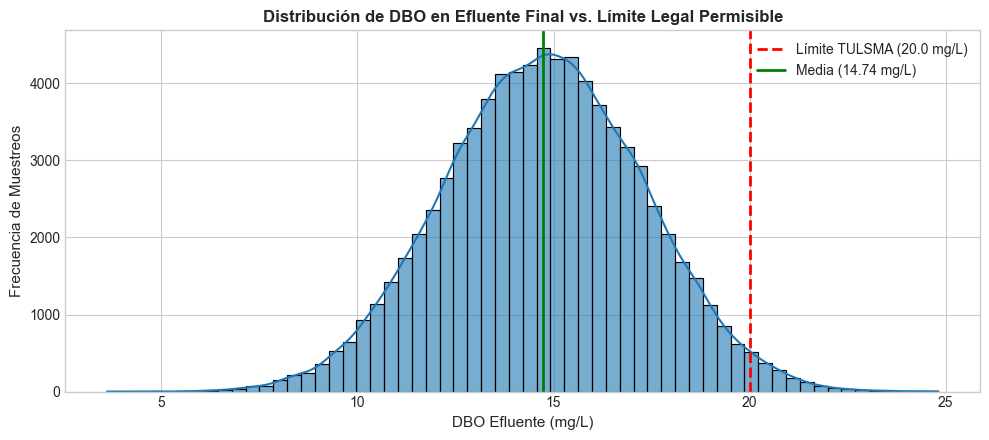

In [6]:
LIMIT_BOD_TULSMA = 20.0

exceedances = df[df['Effluent_BOD_mgL'] > LIMIT_BOD_TULSMA]
total_hours_exceed = (len(exceedances) * 5) / 60.0
pct_exceed = (len(exceedances) / len(df)) * 100.0

print(f"Límite legal ambiental: {LIMIT_BOD_TULSMA} mg/L DBO")
print(f"Lecturas fuera de norma: {len(exceedances):,} de {len(df):,} ({pct_exceed:.2f}%)")
print(f"Tiempo acumulado fuera de norma: {total_hours_exceed:.1f} horas equivalentes")
print(f"Concentración máxima registrada en vertido: {df['Effluent_BOD_mgL'].max():.2f} mg/L")

# Gráfico de distribución de DBO efluente
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(df['Effluent_BOD_mgL'], bins=60, kde=True, color='#1f77b4', ax=ax, edgecolor='black', alpha=0.6)
ax.axvline(LIMIT_BOD_TULSMA, color='red', linestyle='--', linewidth=2, label=f'Límite TULSMA ({LIMIT_BOD_TULSMA} mg/L)')
ax.axvline(df['Effluent_BOD_mgL'].mean(), color='green', linestyle='-', linewidth=2, label=f'Media ({df["Effluent_BOD_mgL"].mean():.2f} mg/L)')
ax.set_title('Distribución de DBO en Efluente Final vs. Límite Legal Permisible', fontweight='bold')
ax.set_xlabel('DBO Efluente (mg/L)')
ax.set_ylabel('Frecuencia de Muestreos')
ax.legend()
plt.tight_layout()
plt.show()

---
## ⏰ 7. Dinámica Diurna (Ciclo de 24 Horas de Planta)
Analizamos el comportamiento de la planta durante los turnos de operación para comprender cómo los sopladores responden a las variaciones horarias de caudal y carga.

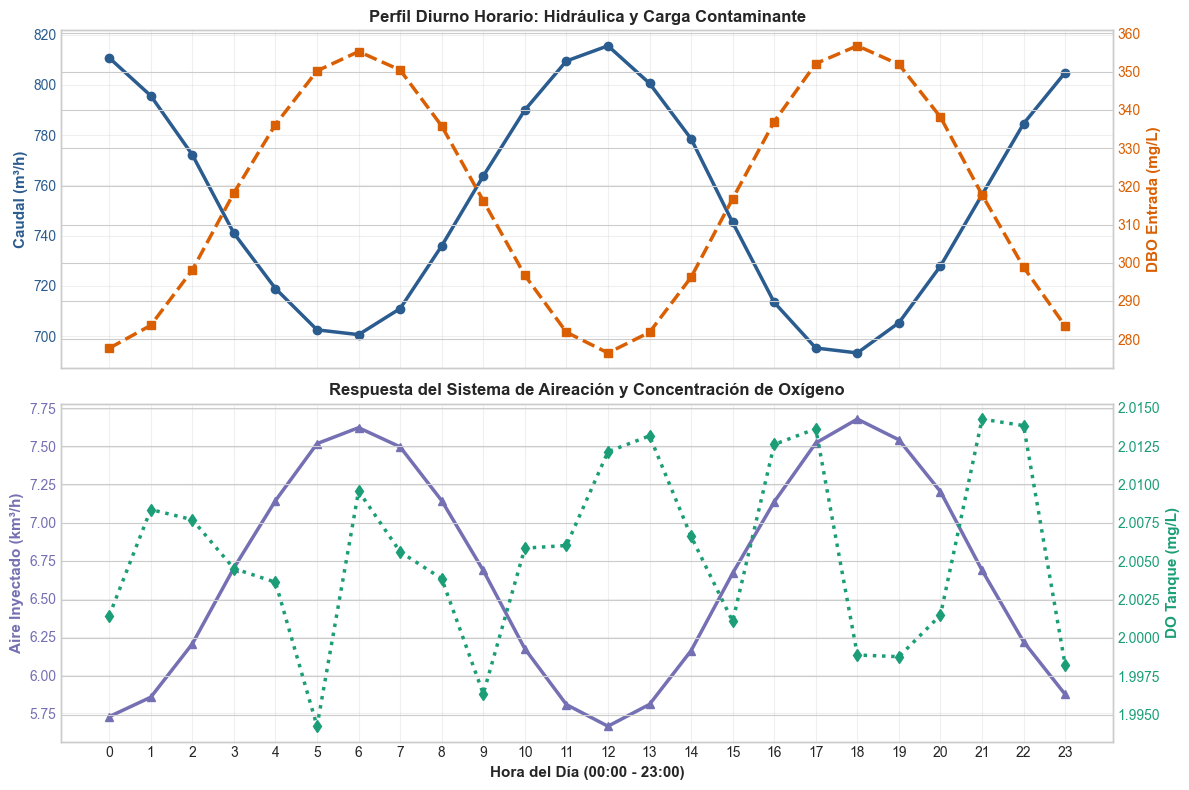

In [7]:
df['Hour'] = df['Timestamp'].dt.hour
diurnal = df.groupby('Hour').agg({
    'Influent_Flow_m3h': 'mean',
    'Influent_BOD_mgL': 'mean',
    'Air_Flow_km3h': 'mean',
    'Aeration_Tank_DO_mgL': 'mean',
    'Effluent_BOD_mgL': 'mean'
}).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Subplot 1: Caudal vs DBO Afluente
color1 = '#2b5c8f'
ax1.plot(diurnal['Hour'], diurnal['Influent_Flow_m3h'], color=color1, marker='o', linewidth=2.5, label='Caudal Entrada (m³/h)')
ax1.set_ylabel('Caudal (m³/h)', color=color1, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax1_twin = ax1.twinx()
color2 = '#d95f02'
ax1_twin.plot(diurnal['Hour'], diurnal['Influent_BOD_mgL'], color=color2, marker='s', linewidth=2.5, linestyle='--', label='DBO Entrada (mg/L)')
ax1_twin.set_ylabel('DBO Entrada (mg/L)', color=color2, fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor=color2)
ax1.set_title('Perfil Diurno Horario: Hidráulica y Carga Contaminante', fontweight='bold')

# Subplot 2: Sopladores (Flujo de Aire) vs Oxígeno Disuelto (DO)
color3 = '#7570b3'
ax2.plot(diurnal['Hour'], diurnal['Air_Flow_km3h'], color=color3, marker='^', linewidth=2.5, label='Flujo de Aire (km³/h)')
ax2.set_ylabel('Aire Inyectado (km³/h)', color=color3, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color3)
ax2.set_xlabel('Hora del Día (00:00 - 23:00)', fontweight='bold')
ax2.grid(True, alpha=0.3)

ax2_twin = ax2.twinx()
color4 = '#1b9e77'
ax2_twin.plot(diurnal['Hour'], diurnal['Aeration_Tank_DO_mgL'], color=color4, marker='d', linewidth=2.5, linestyle=':', label='Oxígeno Disuelto DO (mg/L)')
ax2_twin.set_ylabel('DO Tanque (mg/L)', color=color4, fontweight='bold')
ax2_twin.tick_params(axis='y', labelcolor=color4)
ax2.set_title('Respuesta del Sistema de Aireación y Concentración de Oxígeno', fontweight='bold')
ax2.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

---
## ⏳ 8. Lag Analysis (Correlación Cruzada & Inercia Hidráulica)
En una PTAR, lo que ingresa a la planta no sale de inmediato: recorre el reactor de mezcla completa y los clarificadores secundarios. Cuantificamos la correlación temporal retardada (*cross-correlation*) para identificar la inercia del sistema.

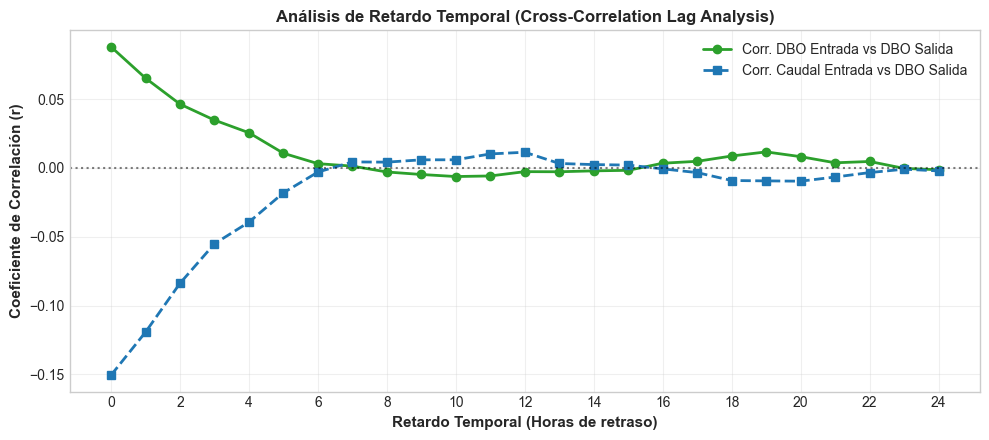

Retardo con máxima influencia de DBO de entrada: 0 horas


In [8]:
max_lag_hours = 24
steps_per_hour = 12  # Intervalo de 5 min -> 12 intervalos por hora

lags_h = list(range(0, max_lag_hours + 1))
corrs_bod = []
corrs_flow = []

for h in lags_h:
    step = h * steps_per_hour
    corrs_bod.append(df['Effluent_BOD_mgL'].corr(df['Influent_BOD_mgL'].shift(step)))
    corrs_flow.append(df['Effluent_BOD_mgL'].corr(df['Influent_Flow_m3h'].shift(step)))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(lags_h, corrs_bod, marker='o', color='#2ca02c', linewidth=2, label='Corr. DBO Entrada vs DBO Salida')
ax.plot(lags_h, corrs_flow, marker='s', color='#1f77b4', linewidth=2, linestyle='--', label='Corr. Caudal Entrada vs DBO Salida')
ax.set_title('Análisis de Retardo Temporal (Cross-Correlation Lag Analysis)', fontweight='bold')
ax.set_xlabel('Retardo Temporal (Horas de retraso)', fontweight='bold')
ax.set_ylabel('Coeficiente de Correlación (r)', fontweight='bold')
ax.set_xticks(range(0, 25, 2))
ax.axhline(0, color='black', linestyle=':', alpha=0.5)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Retardo con máxima influencia de DBO de entrada: {lags_h[np.argmax(corrs_bod)]} horas")

---
## 🧪 9. Control de Sedimentación y Dinámica de Lodos
Evaluamos la relación entre la altura del manto de lodos (`Clarifier_Blanket_Height_m`), la purga (`WAS_Flow_m3h`) y los sólidos suspendidos de salida (`Clarifier_Overflow_TSS_mgL`).

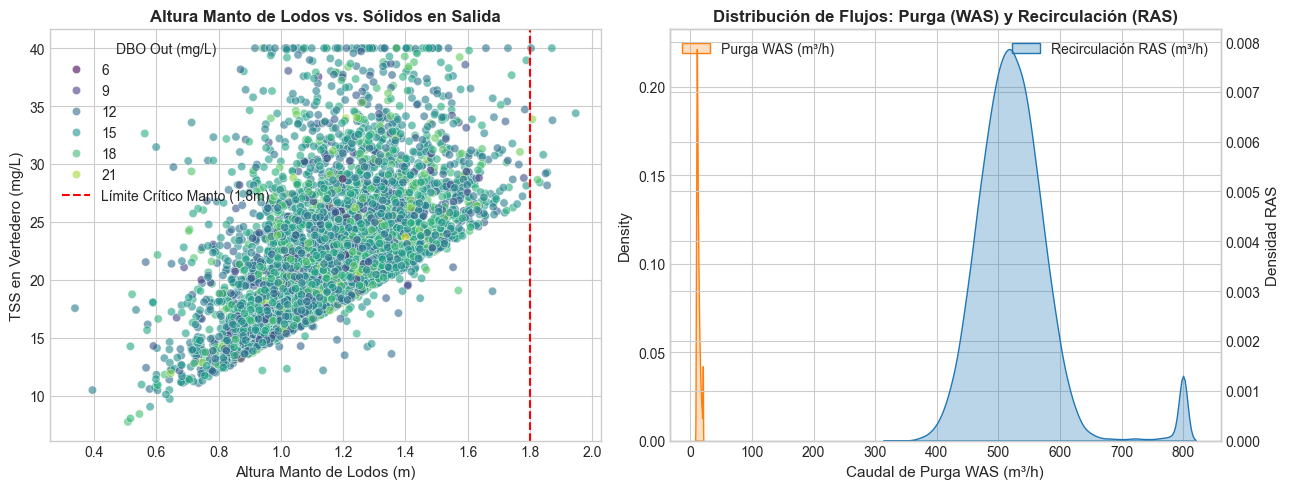

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Relación entre Manto de Lodos y Sólidos en Vertedero
sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='Clarifier_Blanket_Height_m',
    y='Clarifier_Overflow_TSS_mgL',
    hue='Effluent_BOD_mgL',
    palette='viridis',
    alpha=0.6,
    ax=ax1
)
ax1.set_title('Altura Manto de Lodos vs. Sólidos en Salida', fontweight='bold')
ax1.set_xlabel('Altura Manto de Lodos (m)')
ax1.set_ylabel('TSS en Vertedero (mg/L)')
ax1.axvline(1.8, color='red', linestyle='--', label='Límite Crítico Manto (1.8m)')
ax1.legend(title='DBO Out (mg/L)')

# Balance de Purgas (WAS) vs Recirculación (RAS)
sns.kdeplot(df['WAS_Flow_m3h'], ax=ax2, fill=True, color='#ff7f0e', label='Purga WAS (m³/h)')
ax2_twin = ax2.twinx()
sns.kdeplot(df['RAS_Flow_m3h'], ax=ax2_twin, fill=True, color='#1f77b4', alpha=0.3, label='Recirculación RAS (m³/h)')
ax2.set_title('Distribución de Flujos: Purga (WAS) y Recirculación (RAS)', fontweight='bold')
ax2.set_xlabel('Caudal de Purga WAS (m³/h)')
ax2_twin.set_ylabel('Densidad RAS')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

---
## 📌 10. Conclusiones de Ingeniería de Procesos y Siguientes Pasos

1. **Balance de Materia Sólido:** 
   * La planta procesa una carga media de **$5,670\ kg\ DBO/día$** con una remoción biológica media del **$95.28\%$**.
   * El tiempo de retención hidráulica medio en el reactor biológico es de **$5.38\ horas$**.
2. **Diagnóstico Ambiental Crítico:**
   * El sistema presenta **$1,465$ eventos de excedencia** ($1.83\%$ del tiempo, equivalente a $\sim 122$ horas acumuladas) superando el límite de $20\ mg/L$ de DBO.
   * Esto demuestra la necesidad imperativa de un **sistema de alerta temprana predictivo** que anticipe los desvíos.
3. **Comportamiento Diurno y Oportunidad Energética:**
   * La inyección de aire (`Air_Flow_km3h`) oscila en sincronía con los picos diurnos de carga de DBO (06:00 y 18:00).
   * Sin embargo, el oxígeno disuelto se mantiene por encima de $2.0\ mg/L$ e incluso alcanza picos de $>3.5\ mg/L$ en horas valle, lo que evidencia **sobre-aireación y desperdicio eléctrico**.

---
**➡️ Próximo Entregable (Fase 3 - ANALYZE & IMPROVE):**  
En el **Notebook 02 (`02_optimizacion_energia.ipynb`)**, modelaremos la curva de transferencia de oxígeno vs. consumo de sopladores para establecer la zona óptima de consignas ($1.8 - 2.2\ mg/L$) y entrenaremos el modelo predictivo de alerta temprana.